# Definición de funciones (importadas de utils.py)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import math
from typing import Callable, Generator

In [ ]:
def iterate(R: Callable[[complex], complex], z0: complex, max_iter: int):
    """
    Generates the orbit of z0 under the rational function R.
    Yields successive values until max_iter is reached or z escapes to infinity.
    """
    z = z0
    zn = [z0]
    
    for _ in range(max_iter):
        try:
            z = R(z)
            
            # Check for standard float infinity or NaN
            if math.isinf(z.real) or math.isnan(z.real):
                break
                
            zn.append(z)
            
        except (ZeroDivisionError, OverflowError):
            # Hit a pole exactly, or the float overflowed
            break
    
    return zn

In [ ]:
def plot_sequence_dark(zn, center: complex, zoom):
    zn = np.array(zn)
    
    plt.figure(figsize=(10, 10))
    plt.style.use('dark_background')

    # 1. Use a brighter colormap like 'plasma', 'spring', or 'autumn'
    # 'plasma' is great because it goes from bright purple to yellow
    colors = np.linspace(0, 1, len(zn))
    
    # 2. Add a very thin line connecting the points so you can see the 'flow'
    plt.plot(zn.real, zn.imag, color='white', linewidth=0.5, alpha=0.3)

    # 3. Increase size (s) and remove transparency (alpha)
    plt.scatter(zn.real, zn.imag, c=colors, cmap='viridis', s=30, alpha=1.0, edgecolors='none')

    # Highlight start and end with distinct colors
    plt.scatter(zn.real[0], zn.imag[0], color='white', s=50, label='Start (z0)', zorder=5)
    plt.scatter(zn.real[-1], zn.imag[-1], color='red', s=50, label='End', zorder=5)

    plt.axhline(0, color='white', linewidth=0.5, alpha=0.3)
    plt.axvline(0, color='white', linewidth=0.5, alpha=0.3)
    
    # Labels and Grid
    plt.title(f"$z^2$ iterations (Zoom: {zoom})")
    plt.legend(scatterpoints=1)
    plt.grid(alpha=0.1)

    # --- Zoom Settings ---
    plt.xlim(center.real - zoom, center.real + zoom)
    plt.ylim(center.imag - zoom, center.imag + zoom)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.show()

# Ejemplo del libro (Mobius Transformation)

## Comprobación de que eligiendo $\epsilon$ negativo y pequeño, inicialmente diverge

In [4]:
# Transformation coefficients: (az + b) / (cz + d)
# These specific values often lead to interesting spiral behaviors
a, b = 3, -2
c, d = 2, -1

def R(z):
    return (a*z + b)/(c*z + d)

In [5]:
epsilon = -0.01
zeta = 1

z0 = zeta + epsilon

In [6]:
max_iter = 50
zn = iterate(R, z0, max_iter)

Me ha parecido curioso que de repente explote y se vaya al $-10^{12}$

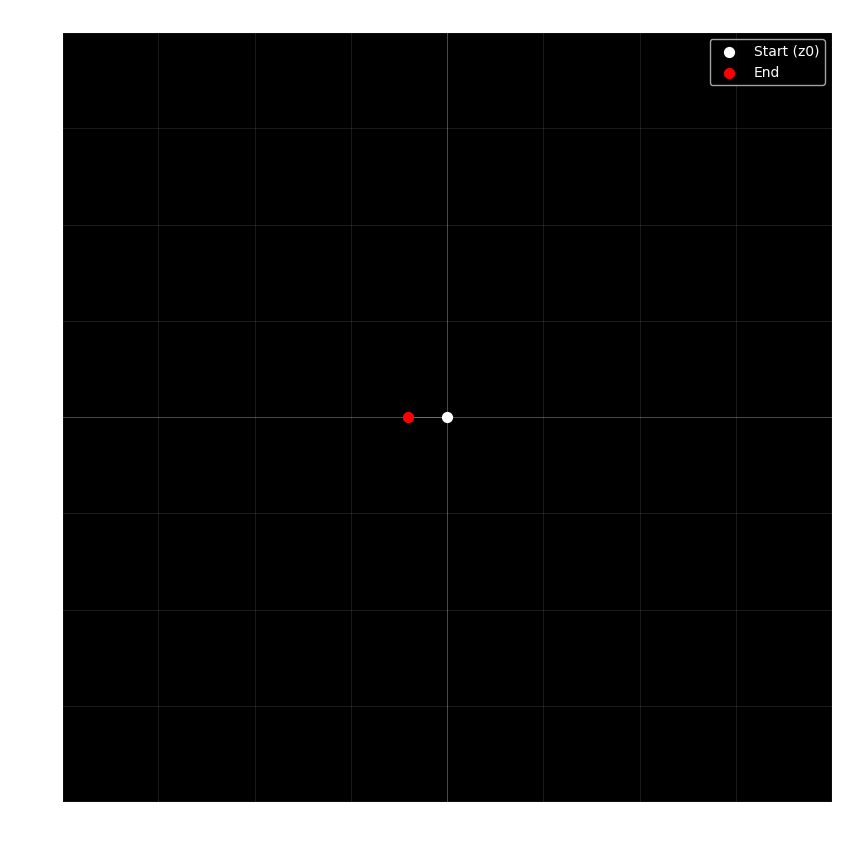

In [7]:
center = complex(1, 0)
zoom = 1e13
plot_sequence_dark(zn, center, zoom)

Para que se vea bien los puntos por los que pasa he decidido mostrarlos como una ristra de números (en vez de en una gráfica)

In [8]:
index = 1
for z in zn:
    print(index, ':\t', z)
    index += 1

1 :	 0.99
2 :	 0.9897959183673467
3 :	 0.9895833333333331
4 :	 0.9893617021276595
5 :	 0.9891304347826084
6 :	 0.9888888888888886
7 :	 0.9886363636363634
8 :	 0.9883720930232557
9 :	 0.9880952380952378
10 :	 0.9878048780487803
11 :	 0.9874999999999999
12 :	 0.9871794871794872
13 :	 0.986842105263158
14 :	 0.9864864864864865
15 :	 0.9861111111111113
16 :	 0.985714285714286
17 :	 0.9852941176470593
18 :	 0.9848484848484854
19 :	 0.9843750000000007
20 :	 0.9838709677419359
21 :	 0.9833333333333338
22 :	 0.9827586206896557
23 :	 0.9821428571428577
24 :	 0.9814814814814821
25 :	 0.9807692307692316
26 :	 0.9800000000000008
27 :	 0.9791666666666674
28 :	 0.9782608695652182
29 :	 0.9772727272727282
30 :	 0.9761904761904769
31 :	 0.9750000000000006
32 :	 0.9736842105263166
33 :	 0.9722222222222229
34 :	 0.9705882352941185
35 :	 0.9687500000000009
36 :	 0.9666666666666677
37 :	 0.9642857142857154
38 :	 0.961538461538463
39 :	 0.958333333333335
40 :	 0.9545454545454568
41 :	 0.9500000000000027
42

Se puede ver con más zoom que las primeras iteraciones diverge

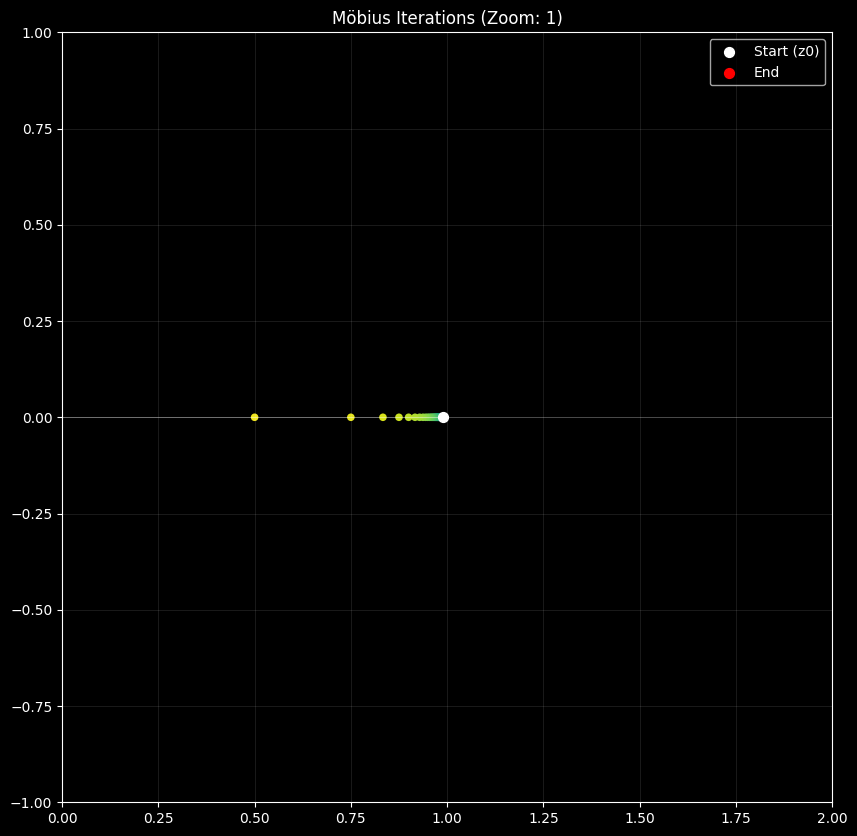

In [9]:
center = complex(1, 0)
zoom = 1
plot_sequence_dark(zn, center, zoom)

## Comprobación de que eventualmente converge

Si cogemos suficientes iteraciones (de hecho después de irse al $-10^{12}$ vuelve al $1.5$), se ve como sigue convergiendo al 1 cómo hemos probado a mano)

In [10]:
epsilon = -0.01
zeta = 1

z0 = zeta + epsilon

In [11]:
max_iter = 100
zn = iterate(R, z0, max_iter)

Aquí se pueden ver las primeras iteraciones que van hacia la izquierda alejándose del 1, pero después vuelve por la derecha

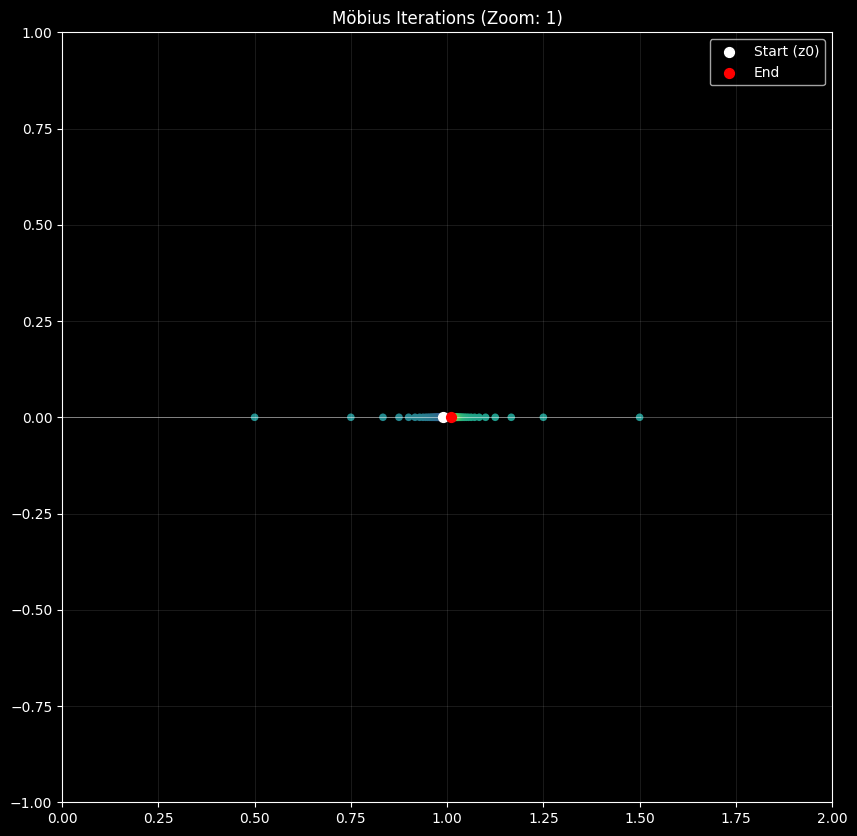

In [12]:
center = complex(1, 0)
zoom = 1
plot_sequence_dark(zn, center, zoom)

Para que se vea bien los puntos por los que pasa he decidido mostrarlos como una ristra de números (en vez de en una gráfica)

In [13]:
i = 1
for z in zn:
    print(i, ':\t', z)
    i += 1

1 :	 0.99
2 :	 0.9897959183673467
3 :	 0.9895833333333331
4 :	 0.9893617021276595
5 :	 0.9891304347826084
6 :	 0.9888888888888886
7 :	 0.9886363636363634
8 :	 0.9883720930232557
9 :	 0.9880952380952378
10 :	 0.9878048780487803
11 :	 0.9874999999999999
12 :	 0.9871794871794872
13 :	 0.986842105263158
14 :	 0.9864864864864865
15 :	 0.9861111111111113
16 :	 0.985714285714286
17 :	 0.9852941176470593
18 :	 0.9848484848484854
19 :	 0.9843750000000007
20 :	 0.9838709677419359
21 :	 0.9833333333333338
22 :	 0.9827586206896557
23 :	 0.9821428571428577
24 :	 0.9814814814814821
25 :	 0.9807692307692316
26 :	 0.9800000000000008
27 :	 0.9791666666666674
28 :	 0.9782608695652182
29 :	 0.9772727272727282
30 :	 0.9761904761904769
31 :	 0.9750000000000006
32 :	 0.9736842105263166
33 :	 0.9722222222222229
34 :	 0.9705882352941185
35 :	 0.9687500000000009
36 :	 0.9666666666666677
37 :	 0.9642857142857154
38 :	 0.961538461538463
39 :	 0.958333333333335
40 :	 0.9545454545454568
41 :	 0.9500000000000027
42

## Generación de puntos iniciales cerca del 1 randoms para ver diferentes comportamientos

In [14]:
radius = 0.5
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 1

z0 = zeta + r

In [15]:
max_iter = 100
zn = iterate(R, z0, max_iter)

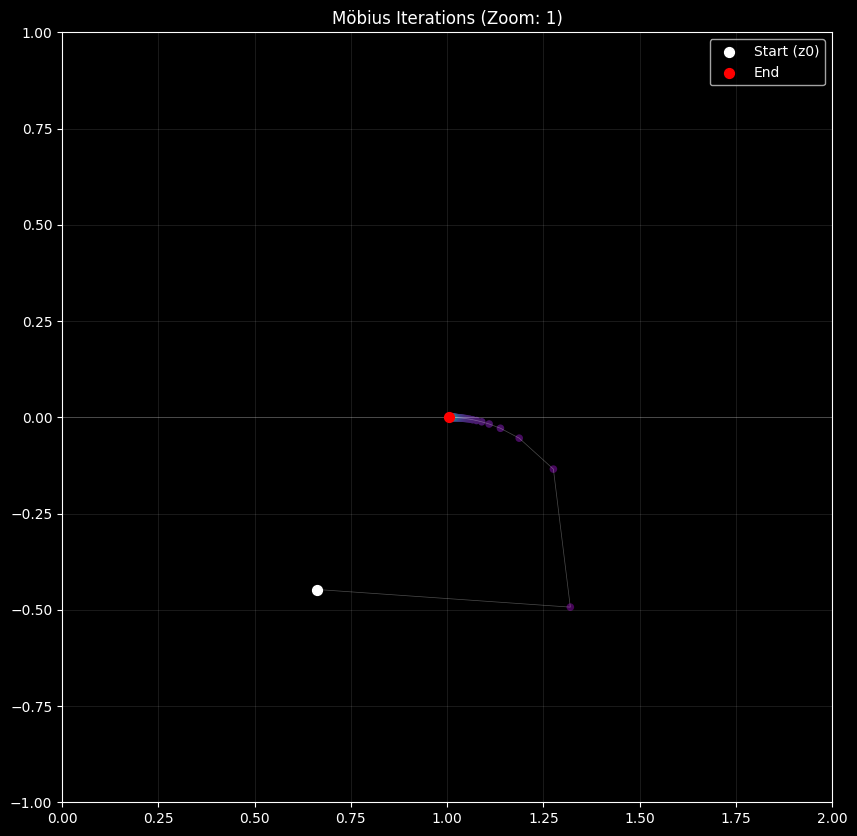

In [16]:
center = complex(1, 0)
zoom = 1
plot_sequence_dark(zn, center, zoom)

# Ejercicio 3

In [17]:
def R(z):
    return 2*z/(z+1)

Hemos analizado en papel que todas las iteraciones hacia atrás parten del 0 ($(R^{-1})^n \to 0$) y hacia adelante llegan al 1 ($R^n \to 1$). Así que voy a tomar puntos aleatorios cerca del 0 (distancia de 0.1 o menos en parte real e imaginaria, y veo cómo llegan al 1). Para ver diferentes puntos iniciales ejecutar varias veces las celdas.

In [18]:
radius = 0.1
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 0

z0 = zeta + r

In [19]:
max_iter = 100
zn = iterate(R, z0, max_iter)

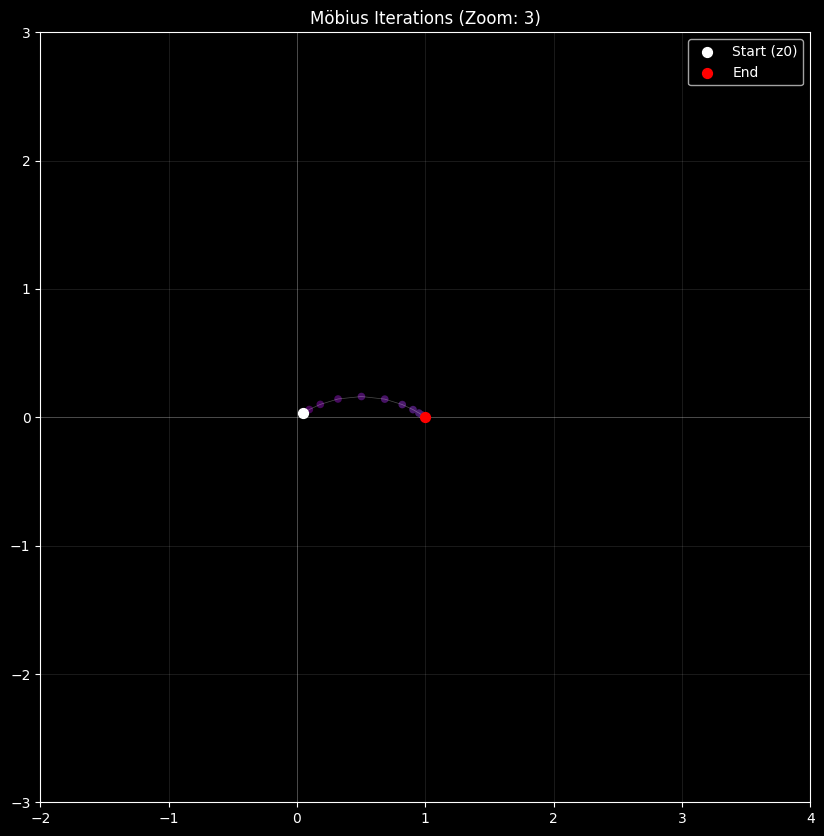

In [20]:
center = complex(1, 0)
zoom = 3
plot_sequence_dark(zn, center, zoom)

Por comodidad para ejecutar multiples veces lo he juntado en una celda

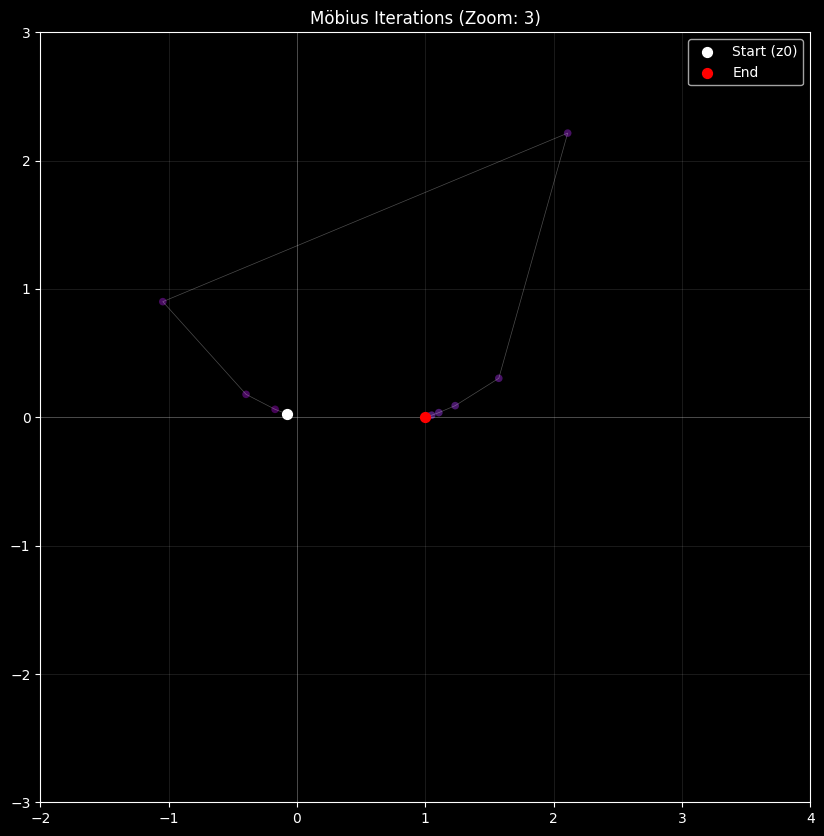

In [21]:
radius = 0.1
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 0

z0 = zeta + r

max_iter = 100
zn = iterate(R, z0, max_iter)

center = complex(1, 0)
zoom = 3
plot_sequence_dark(zn, center, zoom)

# Ejercicio 4

In [22]:
def R(z):
    return z/(2*z+1)

Hemos analizado en papel que tiene un punto fijo indiferente y es 0. Además, todos las secuencias de iteraciones de R eventualmente convergen a 0.

In [23]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 0

z0 = zeta + r

In [24]:
max_iter = 100
zn = iterate(R, z0, max_iter)

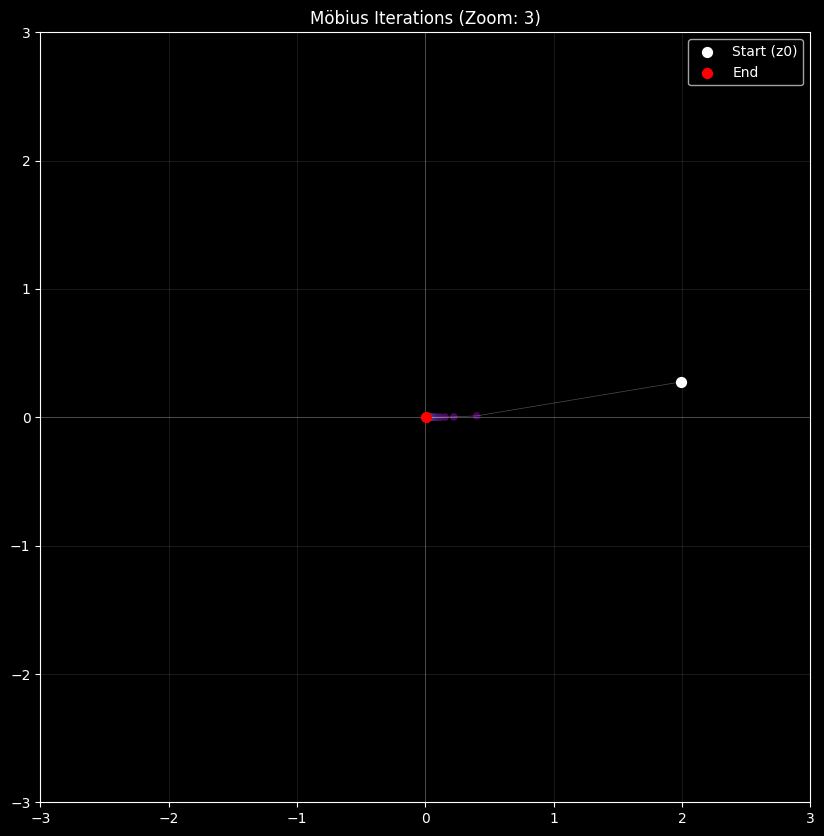

In [25]:
center = complex(0, 0)
zoom = 3
plot_sequence_dark(zn, center, zoom)

Por comodidad para ejecutar multiples veces lo he juntado en una celda

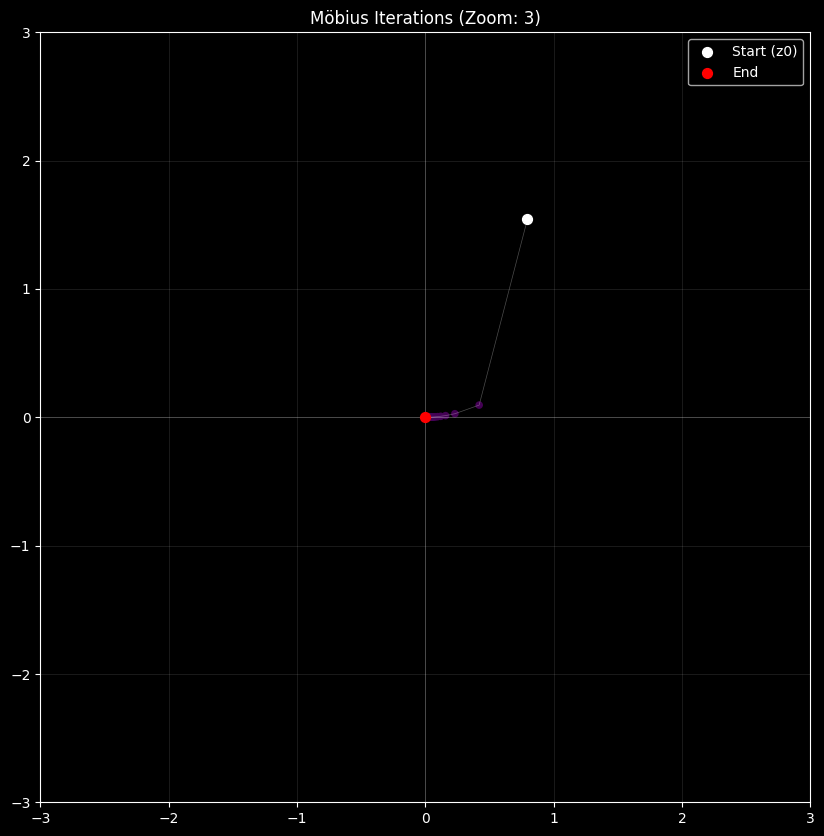

In [26]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta = 0

z0 = zeta + r

max_iter = 1000
zn = iterate(R, z0, max_iter)

center = complex(0, 0)
zoom = 3
plot_sequence_dark(zn, center, zoom)

Hago más zoom para ver si se nota que 0 es indiferente en convergencia más lenta o no se nota nada

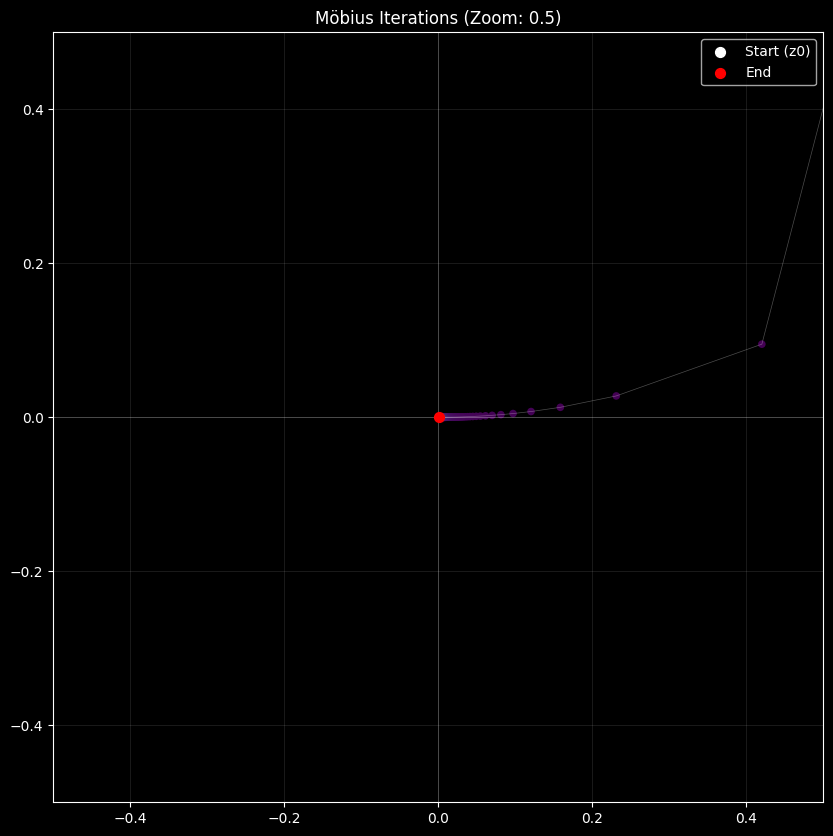

In [27]:
center = complex(0, 0)
zoom = 0.5
plot_sequence_dark(zn, center, zoom)

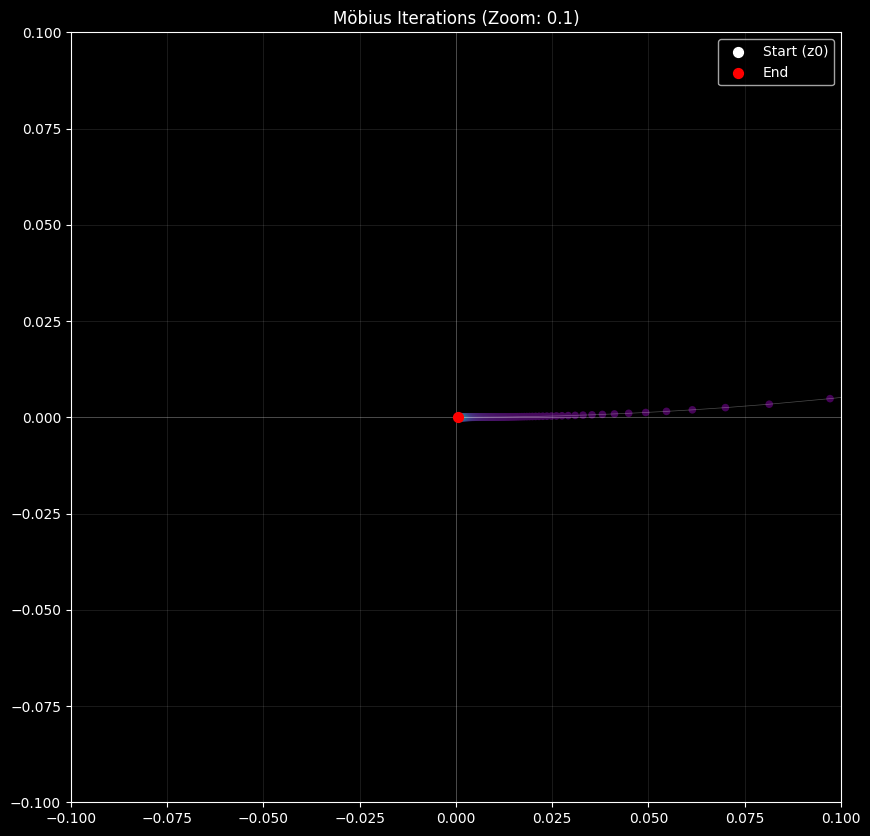

In [28]:
center = complex(0, 0)
zoom = 0.1
plot_sequence_dark(zn, center, zoom)

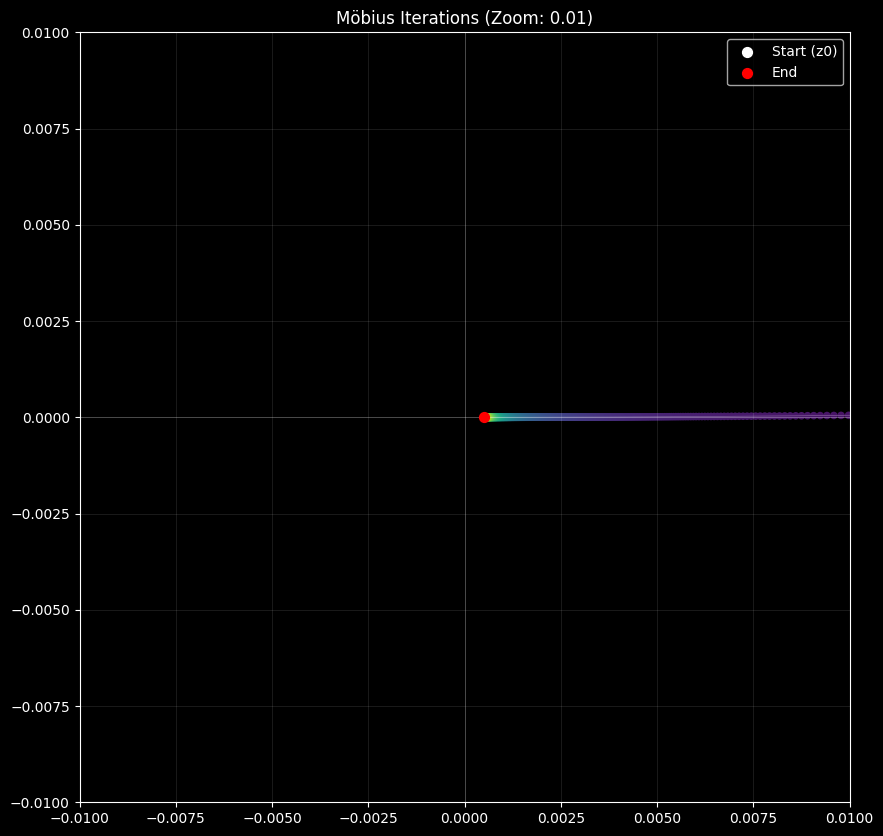

In [29]:
center = complex(0, 0)
zoom = 0.01
plot_sequence_dark(zn, center, zoom)

# Ejercicio 5

In [30]:
a = complex(1, 1)
b = complex(1, -1)

def R(z):
    return (a*z + b)/(b*z + a)

Hemos analizado en papel que tiene dos puntos fijos indiferentes, 1 y -1. Además, todos las secuencias de iteraciones de R son cíclicas de grado 4 (menos las que empiezan en los puntos fijos, que son siempre el punto fijo).

In [41]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta1 = 1
zeta2 = -1

z0 = (zeta1+zeta2)/2 + r

In [42]:
max_iter = 4
zn = iterate(R, z0, max_iter)

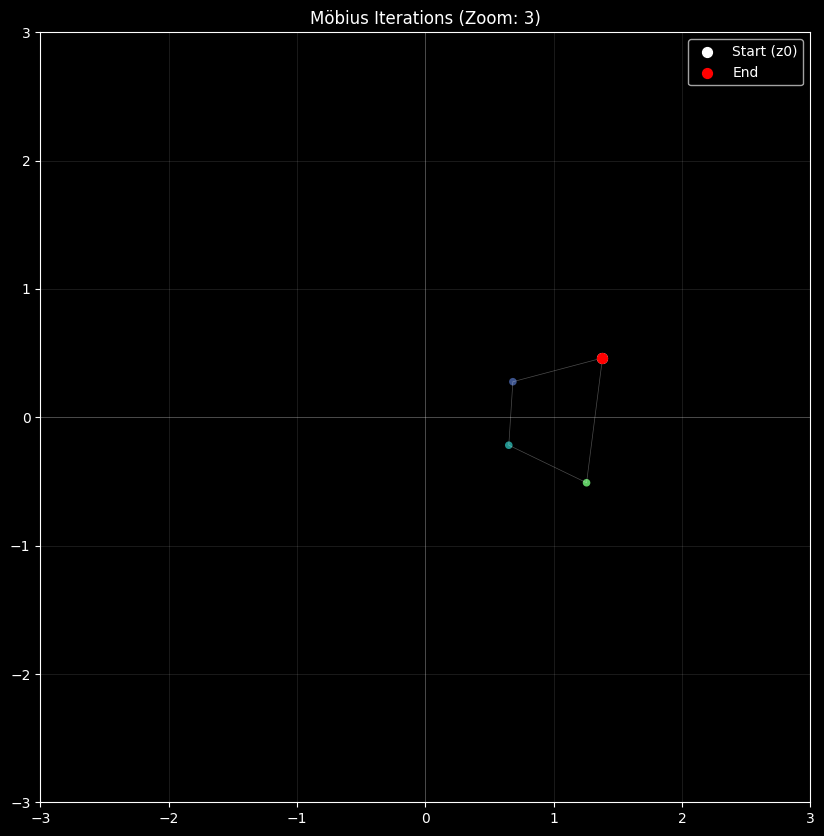

In [43]:
center = complex(0, 0)
zoom = 3
plot_sequence_dark(zn, center, zoom)

Además, sabemos que todos los puntos de la secuencia caen en un círculo o recta, el siguiente código sirve para visualizarlo

(**generado por IA**)

In [46]:
def plot_sequence_dark_for_exercise_5(zn, center, zoom):
    zn = np.array(zn)

    plt.figure(figsize=(10, 10))
    plt.style.use('dark_background')

    colors = np.linspace(0, 1, len(zn))

    # 1. Connect points
    plt.plot(zn.real, zn.imag, color='white', linewidth=0.5, alpha=0.3)

    # 2. Scatter the iterations
    plt.scatter(zn.real, zn.imag, c=colors, cmap='viridis', s=30, alpha=1.0, edgecolors='none')

    # Highlight start and end
    plt.scatter(zn.real[0], zn.imag[0], color='white', s=50, label='Start (z0)', zorder=5)
    plt.scatter(zn.real[-1], zn.imag[-1], color='red', s=50, label='End (z4=z0)', zorder=5)

    # --- NEW: Calculate and Plot the Apollonian Circle ---
    z0 = zn[0]
    C = abs((z0 - 1) / (z0 + 1))

    # Check if the locus is a straight line (imaginary axis)
    if not np.isclose(C, 1.0):
        # Calculate mathematical center
        x_c = (1 + C**2) / (1 - C**2)
        c_circle = complex(x_c, 0)
        radius_circle = abs(z0 - c_circle)

        # Plot the circle center
        plt.scatter(c_circle.real, c_circle.imag, color='#00FFFF', marker='X', s=100, label='Circle Center', zorder=6)

        # Draw the circle locus
        circle = plt.Circle((c_circle.real, c_circle.imag), radius_circle, 
                            color='#00FFFF', fill=False, linestyle='--', linewidth=1.5, alpha=0.5, label='Apollonian Orbit Locus')
        plt.gca().add_patch(circle)
    else:
        plt.axvline(0, color='#00FFFF', linestyle='--', label='Orbit Locus (Imaginary Axis)')

    # Plot the fixed points that govern the geometry
    plt.scatter([1, -1], [0, 0], color='orange', marker='*', s=150, label='Fixed Points (±1)', zorder=7)
    # -----------------------------------------------------

    plt.axhline(0, color='white', linewidth=0.5, alpha=0.3)
    plt.axvline(0, color='white', linewidth=0.5, alpha=0.3)

    # Labels and Grid
    plt.title(f"Möbius Period-4 Orbit (Zoom: {zoom})")
    plt.legend(scatterpoints=1, loc='upper right')
    plt.grid(alpha=0.1)

    # --- Zoom Settings ---
    plt.xlim(center.real - zoom, center.real + zoom)
    plt.ylim(center.imag - zoom, center.imag + zoom)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.show()

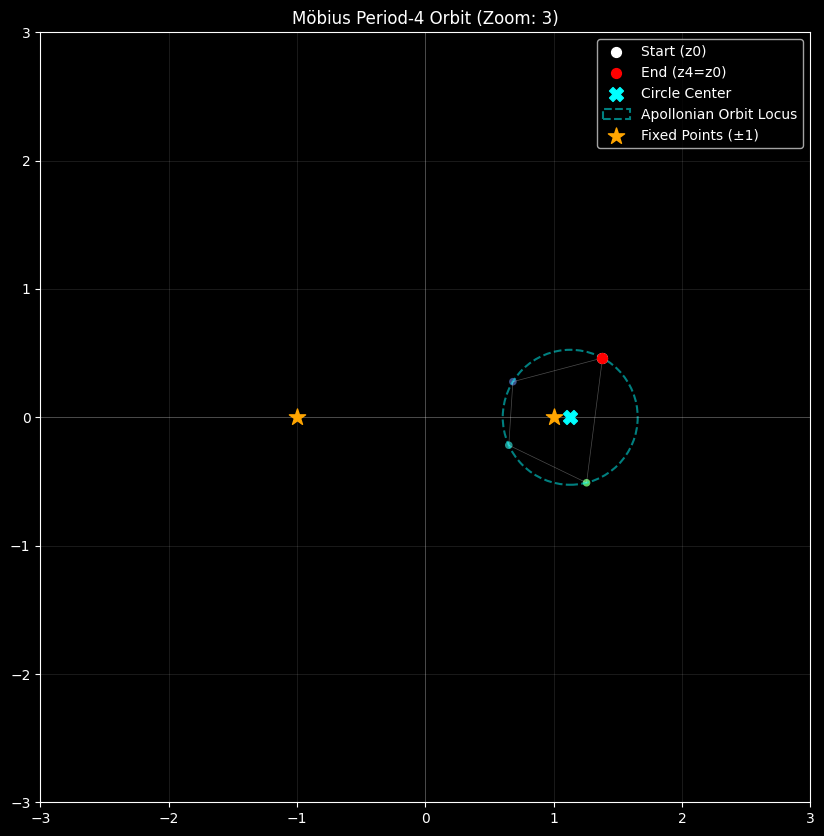

In [47]:
plot_sequence_dark_for_exercise_5(zn, center, zoom)

Por comodidad para ejecutar multiples veces lo he juntado en una celda

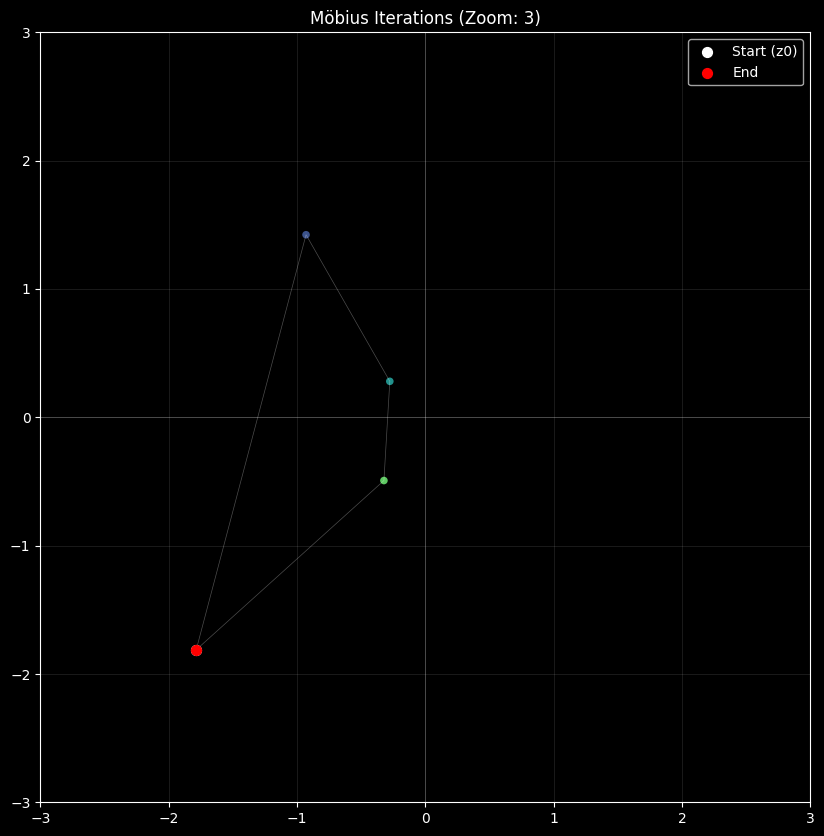

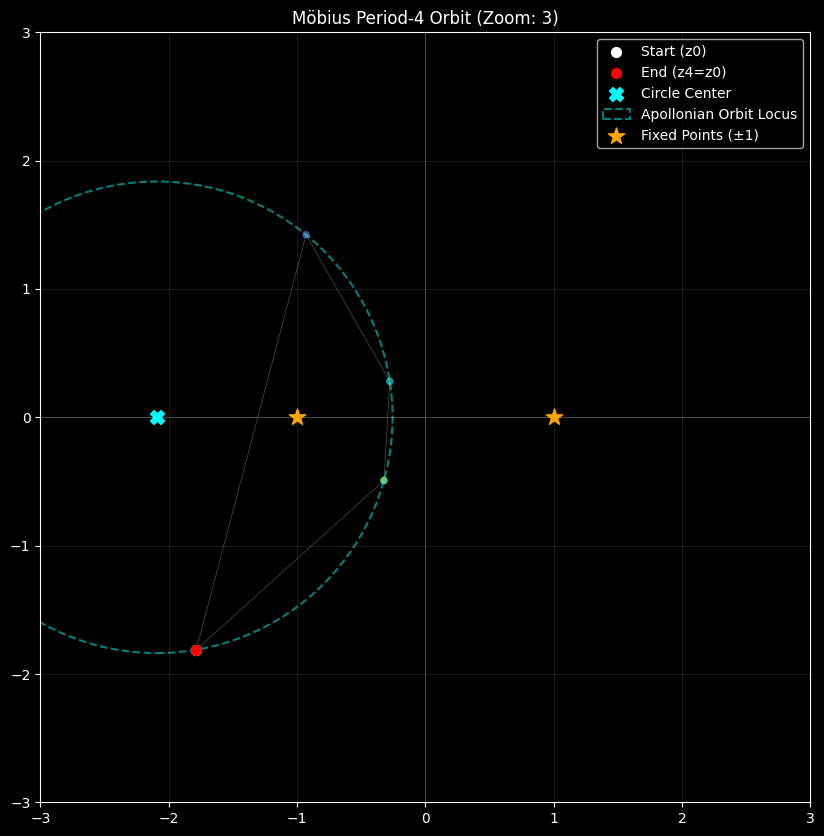

In [54]:
radius = 2
r_real = np.random.uniform(-radius, radius)
r_imag = np.random.uniform(-radius, radius)
r = complex(r_real, r_imag)
zeta1 = 1
zeta2 = -1

z0 = (zeta1+zeta2)/2 + r

max_iter = 4
zn = iterate(R, z0, max_iter)

center = complex(0, 0)
zoom = 3
plot_sequence_dark(zn, center, zoom)
plot_sequence_dark_for_exercise_5(zn, center, zoom)

Pruebo con puntos en el eje imaginario porque me ha salido una vez por azar y se ve que el ciclo puede ser en una recta

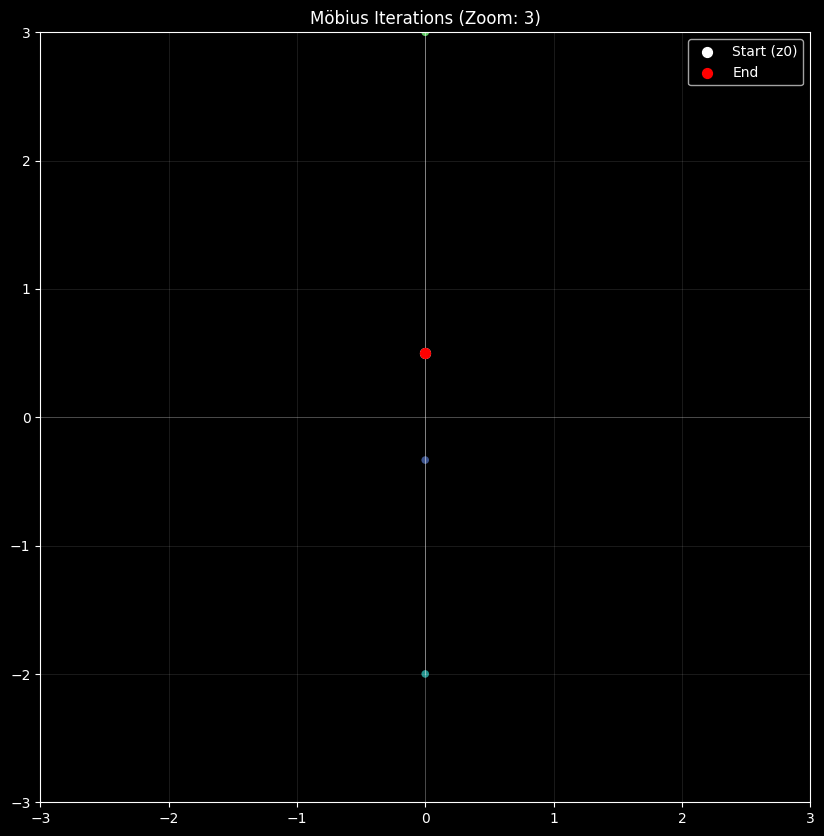

In [49]:
z0 = complex(0, 0.5)

max_iter = 4
zn = iterate(R, z0, max_iter)

center = complex(0, 0)
zoom = 3
plot_sequence_dark(zn, center, zoom)

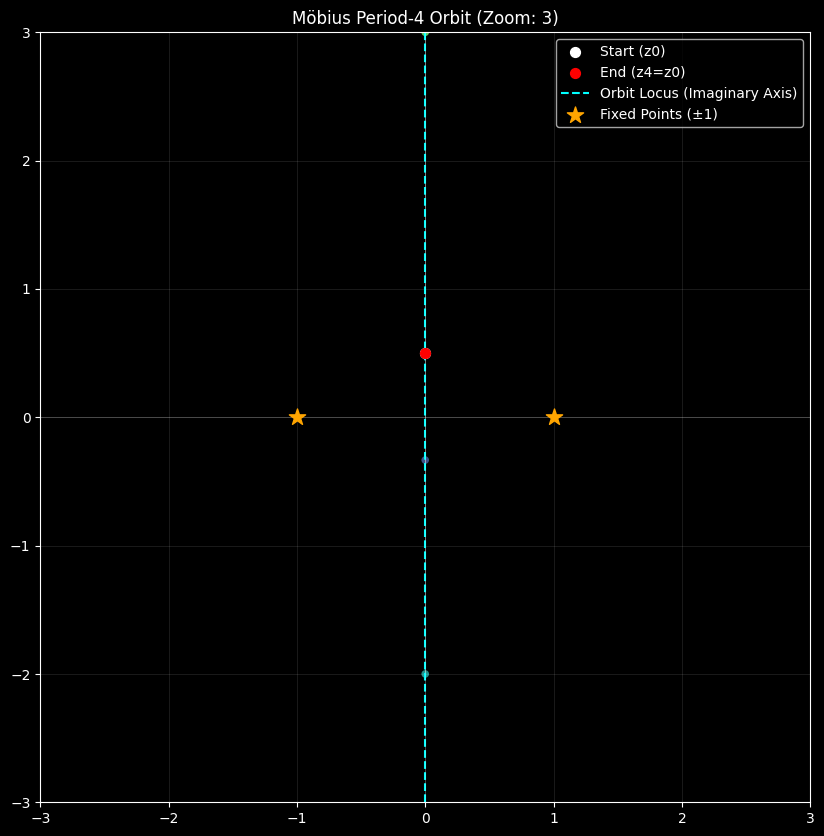

In [50]:
plot_sequence_dark_for_exercise_5(zn, center, zoom)